In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.ndimage import gaussian_filter
import pandas as pd
import scipy.optimize
import math
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they 
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values-average)**2, weights=weights)
    return (average, math.sqrt(variance))

# read_colvar function which sorts colvar for unique entries from the back (i.e., second entry retained)
def read_colvar(colvar_file):

    data = np.loadtxt(colvar_file)
    # inverse order
    data = data[::-1]
    unique_idxs = np.array(np.unique(data[:,0], return_index=True)[1]).astype(int)[::-1] # find unique indices, first occurences
    data = data[unique_idxs]
    # original order
    data = data[::-1]

    return data


path = '/Volumes/Elements/PTM_project/FLN5_proline_METAD/'

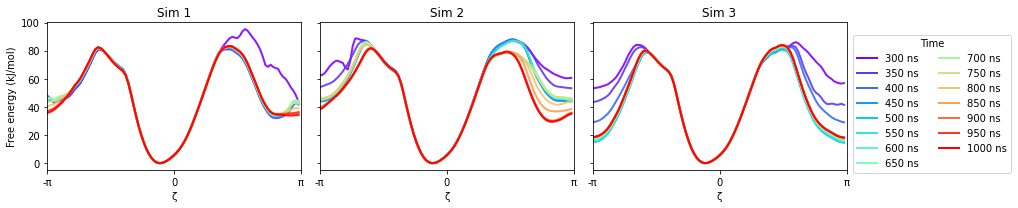

In [3]:
system='FLN5_FL'

T = 298
sims = [1, 2, 3]

times = np.arange(300, 1050, 50)
colors = plt.cm.rainbow(np.linspace(0, 1, len(times)))

frame_per_ns = 1000 / 5
init_frame = int(200 * frame_per_ns)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

# Create legend handles (one per time)
legend_handles = [
    plt.Line2D([0], [0], color=c, lw=2, label=f'{t} ns')
    for t, c in zip(times, colors)
]

for ax, sim in zip(axes, sims):

    data = np.loadtxt(path + f'/{system}/DATA_PLUMED/COLVAR.{sim}')
    CV = data[:, 1]
    rbias = data[:, 3]

    for t, c in zip(times, colors):

        frame = int(t * frame_per_ns)
        if frame <= init_frame:
            continue

        kbt = 0.008314 * T

        rb_slice = rbias[init_frame:frame]
        cv_slice = CV[init_frame:frame]

        weights = np.exp((rb_slice - np.max(rb_slice)) / kbt)
        weights /= np.sum(weights)

        hist, x = np.histogram(cv_slice, weights=weights, bins=100)
        p = hist / np.sum(hist)
        p[p == 0] = 1e-12

        fel = -kbt * np.log(p)
        fel = scipy.ndimage.gaussian_filter(fel, sigma=1)
        fel -= np.min(fel)

        ax.plot(x[:-1], fel, color=c, alpha=0.9, lw=2)

    ax.set_title(f'Sim {sim}')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels(['-\u03C0',0,'\u03C0'])
    ax.set_xlabel('\u03B6')

axes[0].set_ylabel('Free energy (kJ/mol)')

# Add a single shared legend
fig.legend(
    handles=legend_handles,
    loc='center right',
    title='Time',
    ncol=2,
    bbox_to_anchor=(1.18, 0.5)
)

plt.tight_layout()
plt.savefig(f'{system}_rbias_zeta_FEL_timecourse_all_sims.pdf', dpi=300, bbox_inches='tight')



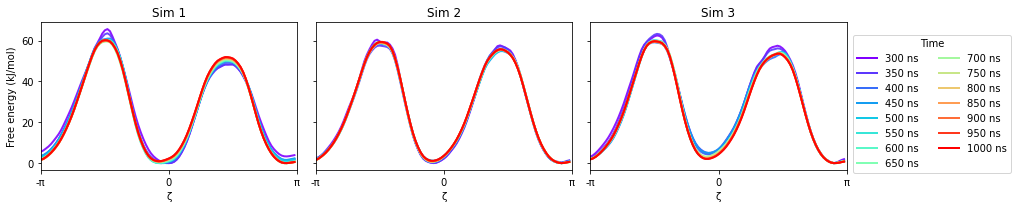

In [4]:
system='FLN5_U'

T = 298
sims = [1, 2, 3]

times = np.arange(300, 1050, 50)
colors = plt.cm.rainbow(np.linspace(0, 1, len(times)))

frame_per_ns = 1000 / 5
init_frame = int(200 * frame_per_ns)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

# Create legend handles (one per time)
legend_handles = [
    plt.Line2D([0], [0], color=c, lw=2, label=f'{t} ns')
    for t, c in zip(times, colors)
]

for ax, sim in zip(axes, sims):

    data = np.loadtxt(path + f'/{system}/DATA_PLUMED/COLVAR.{sim}')
    CV = data[:, 1]
    rbias = data[:, 3]

    for t, c in zip(times, colors):

        frame = int(t * frame_per_ns)
        if frame <= init_frame:
            continue

        kbt = 0.008314 * T

        rb_slice = rbias[init_frame:frame]
        cv_slice = CV[init_frame:frame]

        weights = np.exp((rb_slice - np.max(rb_slice)) / kbt)
        weights /= np.sum(weights)

        hist, x = np.histogram(cv_slice, weights=weights, bins=100)
        p = hist / np.sum(hist)
        p[p == 0] = 1e-12

        fel = -kbt * np.log(p)
        fel = scipy.ndimage.gaussian_filter(fel, sigma=1)
        fel -= np.min(fel)

        ax.plot(x[:-1], fel, color=c, alpha=0.9, lw=2)

    ax.set_title(f'Sim {sim}')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels(['-\u03C0',0,'\u03C0'])
    ax.set_xlabel('\u03B6')

axes[0].set_ylabel('Free energy (kJ/mol)')

# Add a single shared legend
fig.legend(
    handles=legend_handles,
    loc='center right',
    title='Time',
    ncol=2,
    bbox_to_anchor=(1.18, 0.5)
)

plt.tight_layout()
plt.savefig(f'{system}_rbias_zeta_FEL_timecourse_all_sims.pdf', dpi=300, bbox_inches='tight')




In [2]:
# calculate average fraction cis

# average 1D FELs from the triplicates
system='FLN5_FL'
nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+system+'/DATA_PLUMED/COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    frac_cis = np.sum(weights[cisframes])/np.sum(weights)
    cis_data.append(frac_cis)
    
# average and error

mu = [np.round(np.mean(cis_data),3)*100]
err = [np.round(np.std(cis_data)/np.sqrt(nsims),3)*100]

df = pd.DataFrame()
df['Avg %'] = mu
df['Err %']  = err
df.to_csv('avg_fraction_cis_{}.csv'.format(system))
df

,Avg %,Err %
0,100.0,0.0


In [3]:
cis_data

[0.9999977720936797, 0.9999928269342943, 0.9991607170271029]

In [4]:
# calculate average fraction cis

# average 1D FELs from the triplicates
system='FLN5_U'
nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, discarding first 200


cis_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+system+'/DATA_PLUMED/COLVAR.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/5)
    init_frame = int((times[0]-(times[1]-times[0]))*1000/5)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[init_frame:frame]-np.amax(rbias[init_frame:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[init_frame:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    frac_cis = np.sum(weights[cisframes])/np.sum(weights)
    cis_data.append(frac_cis)
    
# average and error

mu = [np.round(np.mean(cis_data),3)*100]
err = [np.round(np.std(cis_data)/np.sqrt(nsims),3)*100]

df = pd.DataFrame()
df['Avg %'] = mu
df['Err %']  = err
df.to_csv('avg_fraction_cis_{}.csv'.format(system))
df

,Avg %,Err %
0,33.6,2.8


In [5]:
cis_data

[0.38694666048551873, 0.3490457024030624, 0.27204026159281397]

In [6]:
## COMPARISON WITH FINAL BIAS

In [6]:
# calculate average fraction cis

# average 1D FELs from the triplicates
system='FLN5_FL'
nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, no transient discarded below


cis_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+system+'/final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[:frame]-np.amax(rbias[:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    frac_cis = np.sum(weights[cisframes])/np.sum(weights)
    cis_data.append(frac_cis)
    
# average and error

mu = [np.round(np.mean(cis_data),3)*100]
err = [np.round(np.std(cis_data)/np.sqrt(nsims),3)*100]

df = pd.DataFrame()
df['Avg %'] = mu
df['Err %']  = err
df.to_csv('avg_fraction_cis_{}_finalbias.csv'.format(system))
df

,Avg %,Err %
0,100.0,0.0


In [7]:
cis_data

[0.9999926337969586, 0.9999882218115169, 0.9999956105883326]

In [7]:
# calculate average fraction cis

# average 1D FELs from the triplicates
system='FLN5_U'
nsims=3

# time course convergence
T=298

times = np.arange(220,1020,20)
t=times[-1] # at 1000ns, no transient discarded below


cis_data = []

for s in range(1,nsims+1):
    data = read_colvar(path+system+'/final_bias_from_hills_1us/COLVAR_REW.{}'.format(s))
    CV = data[:,1]
    rbias = data[:,3]
    frame = int(t*1000/20)
    
    # FEL rbias reweighting
    kbt = 0.008314*T
    weights = np.exp((rbias[:frame]-np.amax(rbias[:frame]))/kbt)
    weights = weights/np.sum(weights)
    
    
    cisframes = np.where(np.abs(CV[:frame])<1.4)[0] # abs zeta angle less than ~80 deg
    frac_cis = np.sum(weights[cisframes])/np.sum(weights)
    cis_data.append(frac_cis)
    
# average and error

mu = [np.round(np.mean(cis_data),3)*100]
err = [np.round(np.std(cis_data)/np.sqrt(nsims),3)*100]

df = pd.DataFrame()
df['Avg %'] = mu
df['Err %']  = err
df.to_csv('avg_fraction_cis_{}_finalbias.csv'.format(system))
df

,Avg %,Err %
0,30.5,2.6


In [8]:
cis_data

[0.3125910819206904, 0.2469458366242705, 0.35427537563124084]